# NOTEBOOK: Random Forest Regression

 Goal: Implement and evaluate Random Forest Regression

## Setup

In [2]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import data_loader
from src.eda import (
    analyze_data,
    plot_feature_target_relationships
)
from src.preprocessing import DataPreprocessor
from src.data_utils import split_train_test
from src.models.supervised import SKLearnRandomForestRegressor
from src.models.unsupervised import SKLearnPCA

from src.models.supervised.model_selection import (
    k_fold_cross_validation, 
    plot_cross_validation_results,
    grid_search_cv,
    plot_grid_search_results
)

2025-12-30 02:13:47.224697: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Data Loading & Exploration

DATA ANALYSIS

Dataset shape: 1460 rows × 80 columns

Data types:
Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MiscVal            int64
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
Length: 80, dtype: object

Missing values:
              Missing_Count  Missing_Percent
PoolQC                 1453            99.52
MiscFeature            1406            96.30
Alley                  1369            93.77
Fence                  1179            80.75
FireplaceQu             690            47.26
LotFrontage             259            17.74
GarageType               81             5.55
GarageYrBlt              81             5.55
GarageFinish             81             5.55
GarageQual               81             5.55
GarageCond               81             5.55
BsmtExposure             38             2.60
BsmtFinType2             38    

/Users/cdubois/workshop/ml-fundamentals/src/eda.py:545: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/Users/cdubois/workshop/ml-fundamentals/src/eda.py:552: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


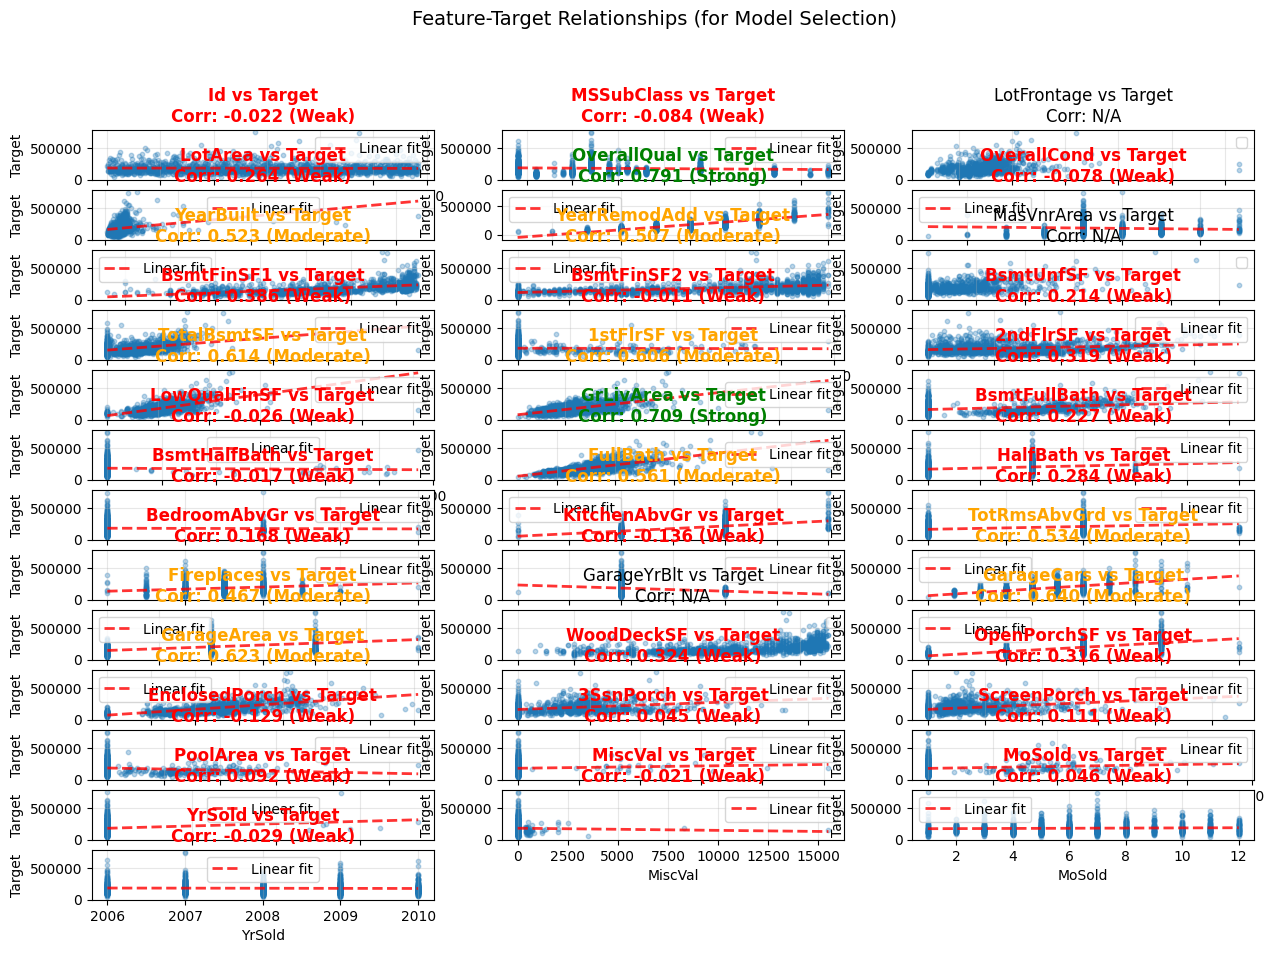

In [3]:
# Load data
# Quick EDA: shape, dtypes, missing values, class distribution
# Feature/target split

X, y = data_loader.load_ames_housing()

analyze_data(X, show_stats=True)
plot_feature_target_relationships(X, y)

## Preprocess Data

In [4]:


# Split
X_train, X_test, y_train, y_test = split_train_test(X, y, test_size=0.2, random_state=42)

# Preprocess
preprocessor = DataPreprocessor(scale=False, encode_categorical=True) # No scaling for tree-based models
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print(f"Training set: {X_train_proc.shape}")
print(f"Test set: {X_test_proc.shape}")
print(f"\nFeature names after preprocessing:")
print(preprocessor.get_feature_names())


DataPreprocessor: fit_transform

1. Column types:
   Numerical: 37 columns
   Nominal categorical: 43 columns
   Ordinal categorical: 0 columns

2. Processing numerical columns...
   ✓ Applied median imputation

3. Processing nominal categorical columns...
   ✓ Applied most_frequent imputation
   ✓ One-hot encoding 43 nominal columns...
   → Created 250 one-hot features

4. Processing ordinal categorical columns...

Final shape: 1168 rows × 287 features

Training set: (1168, 287)
Test set: (292, 287)

Feature names after preprocessing:
['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenP

## Baseline Model

In [5]:
model = SKLearnRandomForestRegressor()
model.fit(X_train_proc, y_train)

baseline_score = model.score(X_test_proc, y_test)
print("✓ Model trained successfully")

✓ Model trained successfully


## Baseline Evaluation & Diagnostics


MODEL EVALUATION
R² Score: 0.8900
RMSE: 29053.5768
MAE: 17873.4499

💡 Good performance (R² ≥ 0.75)


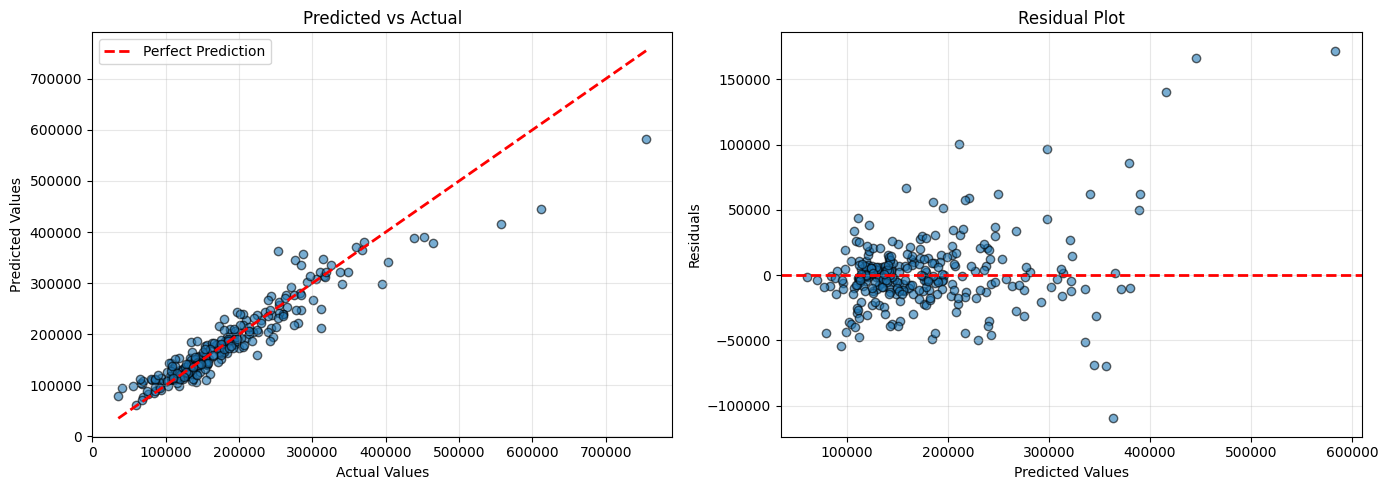


💡 How to interpret:
   • Predicted vs Actual: Points close to red line = good predictions
   • Residual Plot: Random scatter around zero = good model fit
   • Patterns in residuals = model is missing something


In [6]:
y_pred = model.predict(X_test_proc)
r2 = model.score(X_test_proc, y_test)
rmse = np.sqrt(model.mean_squared_error(X_test_proc, y_test))
mae = model.mean_absolute_error(X_test_proc, y_test)

print("\n" + "="*70)
print("MODEL EVALUATION")
print("="*70)
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

if r2 >= 0.90:
    print("\n💡 Excellent performance (R² ≥ 0.90)")
elif r2 >= 0.75:
    print("\n💡 Good performance (R² ≥ 0.75)")
elif r2 >= 0.60:
    print("\n💡 Moderate performance (R² ≥ 0.60)")
else:
    print("\n💡 Room for improvement (R² < 0.60)")

# Residual analysis
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
axes[0].scatter(y_test, y_pred, alpha=0.6, edgecolors='black')
axes[0].plot([y_test.min(), y_test.max()], 
            [y_test.min(), y_test.max()], 
            'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Values')
axes[0].set_ylabel('Predicted Values')
axes[0].set_title('Predicted vs Actual')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals
axes[1].scatter(y_pred, residuals, alpha=0.6, edgecolors='black')
axes[1].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Interpretation
print("\n💡 How to interpret:")
print("   • Predicted vs Actual: Points close to red line = good predictions")
print("   • Residual Plot: Random scatter around zero = good model fit")
print("   • Patterns in residuals = model is missing something")

## K-Fold Cross-Validation for Robust Evaluation


K-FOLD CROSS-VALIDATION
K-FOLD CROSS-VALIDATION (k=5)
Task: Regression
Scoring: r2
Total samples: 1168

Fold 1/5: r2=0.8846 (train: 934, test: 234)
Fold 2/5: r2=0.8018 (train: 934, test: 234)
Fold 3/5: r2=0.7833 (train: 934, test: 234)
Fold 4/5: r2=0.8690 (train: 935, test: 233)
Fold 5/5: r2=0.8622 (train: 935, test: 233)

CROSS-VALIDATION RESULTS
Mean r2: 0.8402 ± 0.0400
Min r2:  0.7833
Max r2:  0.8846


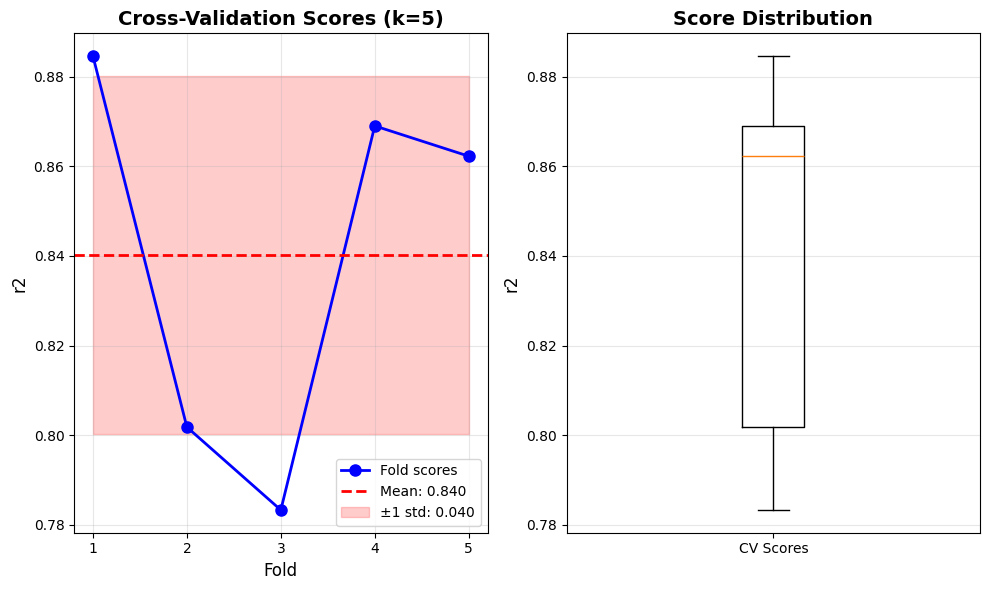


💡 Cross-validation provides more reliable estimate:
   Single test split: 0.8900
   5-fold CV: 0.8402 ± 0.0400


In [7]:
print("\n" + "="*70)
print("K-FOLD CROSS-VALIDATION")
print("="*70)

# Perform 5-fold cross-validation
cv_baseline = k_fold_cross_validation(
    model=model,  # Use same model as before
    X=X_train_proc,
    y=y_train,
    k=5,
    scoring='r2'
)

# Visualize
plot_cross_validation_results(cv_baseline)

print(f"\n💡 Cross-validation provides more reliable estimate:")
print(f"   Single test split: {r2:.4f}")
print(f"   5-fold CV: {cv_baseline['mean']:.4f} ± {cv_baseline['std']:.4f}")

## Dimensionality Reduction Visualization


PCA 2D VISUALIZATION

PCA PROJECTION - REGRESSION
Target range: [34900.00, 745000.00]
💡 Color intensity = target value magnitude
   • Darker colors = lower values
   • Lighter colors = higher values
   Look for patterns: Do similar values cluster together?


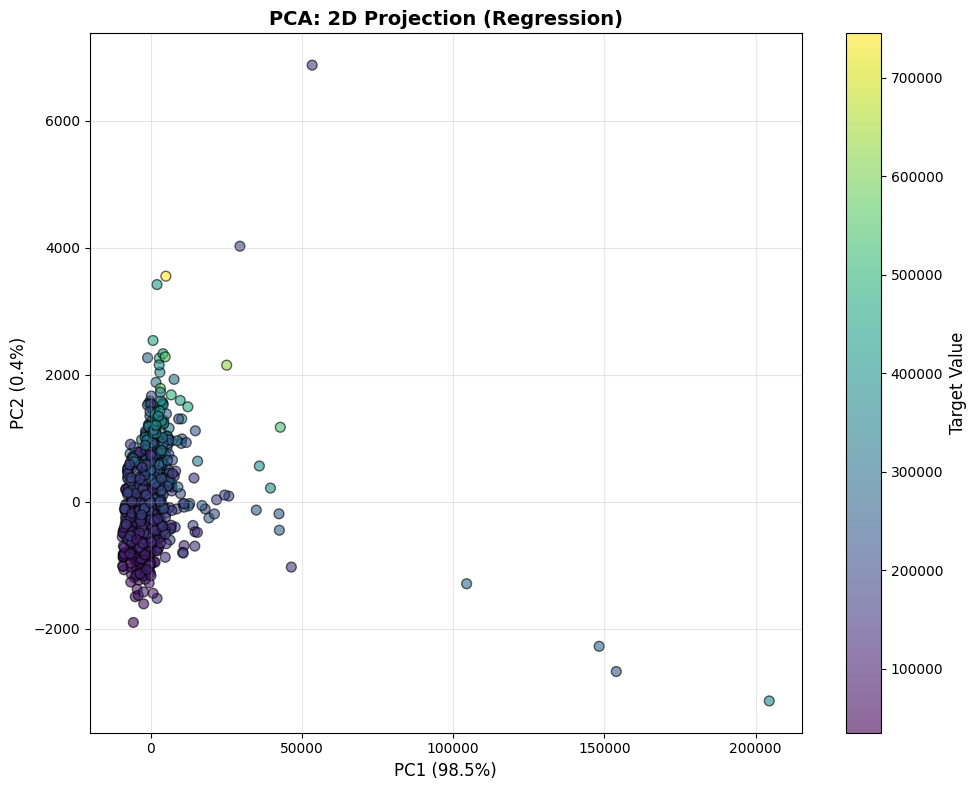


Variance explained:
  PC1: 98.5%
  PC2: 0.4%
  Total: 98.9%


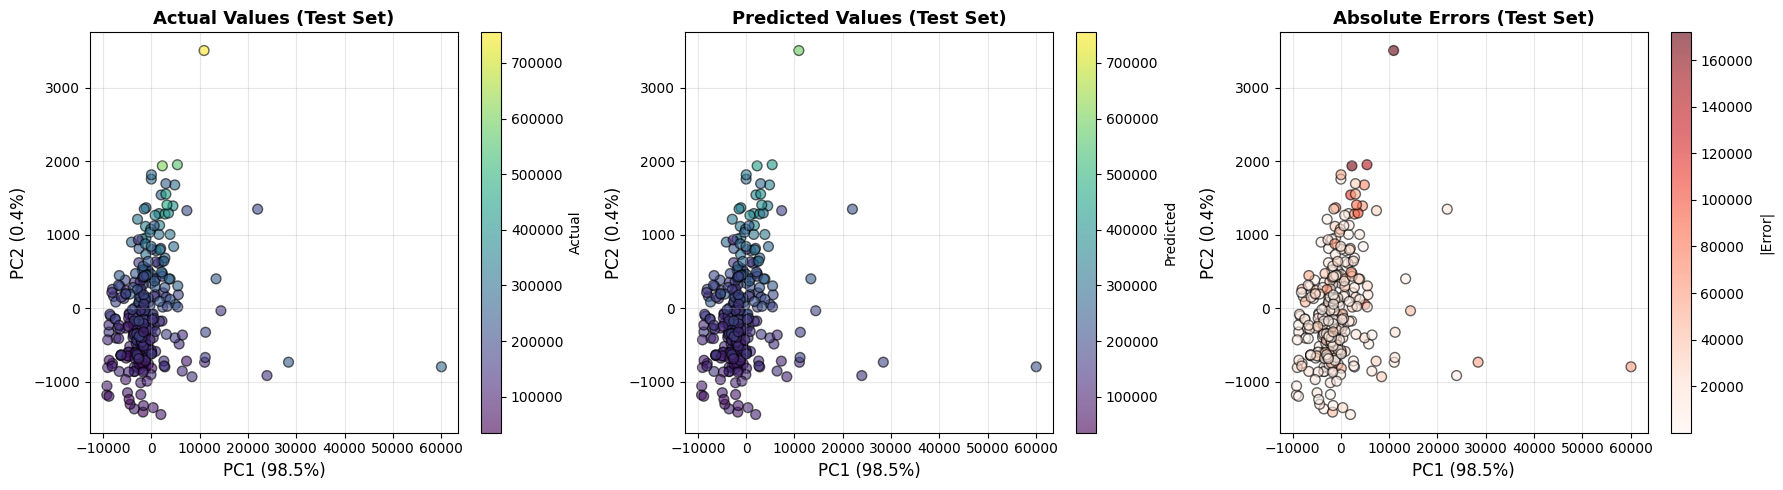


REGRESSION PROJECTION ANALYSIS

Target range: [35311.00, 755000.00]
Mean absolute error: 17873.45
Max absolute error: 171927.34

💡 Interpretation:
   • Similar colors (left vs middle) → Good predictions
   • Different colors → Prediction errors
   • Red areas (right plot) → High error regions
   • Look for spatial patterns: Are errors clustered?


In [8]:
print("\n" + "="*70)
print("PCA 2D VISUALIZATION")
print("="*70)

pca = SKLearnPCA(n_components=2)
pca.fit(X_train_proc)
pca.plot_2d_projection(X_train_proc, y_train, task='regression')
pca.plot_regression_projection_with_predictions(
    X_test_proc, y_test, y_pred, 
    title_suffix="Test Set"
)

## Hyper-Parameter Tuning

In [ ]:
print("\n" + "="*70)
print("HYPERPARAMETER TUNING")
print("="*70)

# Define parameter grid based on model
param_grid = {
    'n_estimators': [20, 30, 40, 50],
    'max_depth': [5, 10, 15, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

grid_results = grid_search_cv(
    model_class=SKLearnRandomForestRegressor,
    param_grid=param_grid,
    X=X_train_proc,
    y=y_train,
    cv=5,
    verbose=True
)

# Visualize grid search results (if 2 parameters)
if len(param_grid) >= 2:
    param_names = list(param_grid.keys())
    plot_grid_search_results(grid_results, param_names[0], param_names[1])

print(f"\n✓ Best parameters: {grid_results['best_params']}")
print(f"✓ Best CV score: {grid_results['best_score']:.4f}")


HYPERPARAMETER TUNING
GRID SEARCH WITH CROSS-VALIDATION
Parameter grid:
  n_estimators: [20, 30, 40, 50]

Total combinations to test: 4
Cross-validation folds: 5
Total fits: 20

K-FOLD CROSS-VALIDATION (k=5)
Task: Regression
Scoring: r2
Total samples: 1168

Fold 1/5: r2=0.8596 (train: 934, test: 234)
Fold 2/5: r2=0.7871 (train: 934, test: 234)
Fold 3/5: r2=0.7492 (train: 934, test: 234)
Fold 4/5: r2=0.8677 (train: 935, test: 233)
Fold 5/5: r2=0.8647 (train: 935, test: 233)

CROSS-VALIDATION RESULTS
Mean r2: 0.8257 ± 0.0485
Min r2:  0.7492
Max r2:  0.8677
[1/4] {'n_estimators': 20, 'random_state': 42}
  → r2: 0.8257 ± 0.0485

K-FOLD CROSS-VALIDATION (k=5)
Task: Regression
Scoring: r2
Total samples: 1168

Fold 1/5: r2=0.8622 (train: 934, test: 234)
Fold 2/5: r2=0.8039 (train: 934, test: 234)
Fold 3/5: r2=0.7680 (train: 934, test: 234)
Fold 4/5: r2=0.8735 (train: 935, test: 233)
Fold 5/5: r2=0.8648 (train: 935, test: 233)

CROSS-VALIDATION RESULTS
Mean r2: 0.8345 ± 0.0414
Min r2:  0.7680

## Final Model Evaluation


MODEL EVALUATION
R² Score: 0.8873
RMSE: 29395.6421
MAE: 17949.1471

💡 Good performance (R² ≥ 0.75)


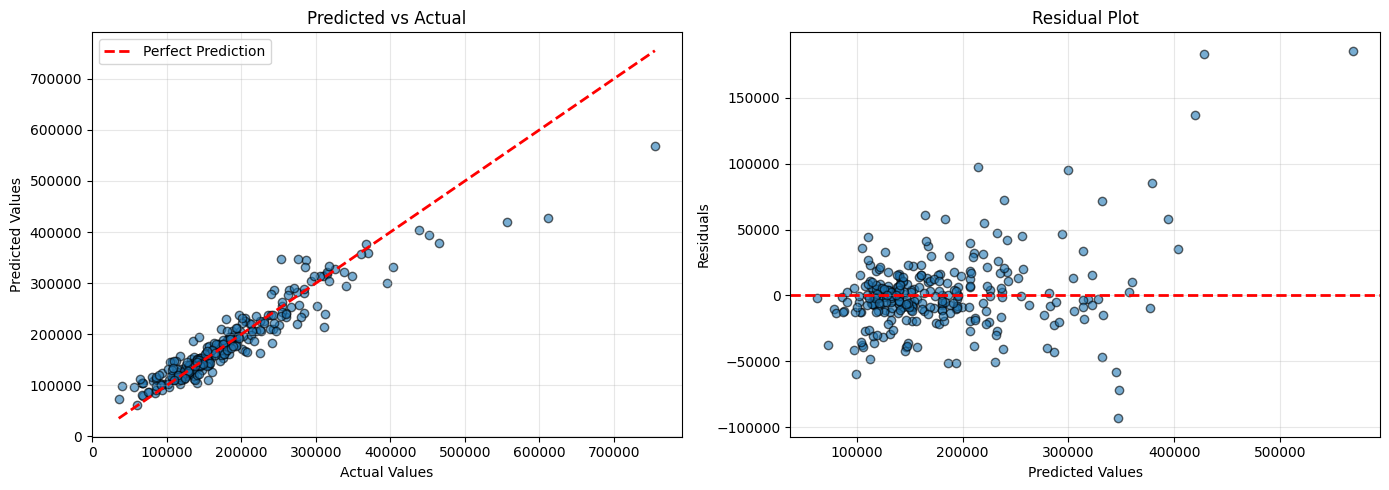


💡 How to interpret:
   • Predicted vs Actual: Points close to red line = good predictions
   • Residual Plot: Random scatter around zero = good model fit
   • Patterns in residuals = model is missing something


In [16]:
best_model = grid_results['best_model']

final_score = best_model.score(X_test_proc, y_test)

final_y_pred = best_model.predict(X_test_proc)
final_r2 = best_model.score(X_test_proc, y_test)
final_rmse = np.sqrt(best_model.mean_squared_error(X_test_proc, y_test))
final_mae = best_model.mean_absolute_error(X_test_proc, y_test)

print("\n" + "="*70)
print("MODEL EVALUATION")
print("="*70)
print(f"R² Score: {final_r2:.4f}")
print(f"RMSE: {final_rmse:.4f}")
print(f"MAE: {final_mae:.4f}")

if final_r2 >= 0.90:
    print("\n💡 Excellent performance (R² ≥ 0.90)")
elif final_r2 >= 0.75:
    print("\n💡 Good performance (R² ≥ 0.75)")
elif final_r2 >= 0.60:
    print("\n💡 Moderate performance (R² ≥ 0.60)")
else:
    print("\n💡 Room for improvement (R² < 0.60)")

# Residual analysis
residuals = y_test - final_y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
axes[0].scatter(y_test, final_y_pred, alpha=0.6, edgecolors='black')
axes[0].plot([y_test.min(), y_test.max()], 
            [y_test.min(), y_test.max()], 
            'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Values')
axes[0].set_ylabel('Predicted Values')
axes[0].set_title('Predicted vs Actual')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals
axes[1].scatter(final_y_pred, residuals, alpha=0.6, edgecolors='black')
axes[1].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Interpretation
print("\n💡 How to interpret:")
print("   • Predicted vs Actual: Points close to red line = good predictions")
print("   • Residual Plot: Random scatter around zero = good model fit")
print("   • Patterns in residuals = model is missing something")

## Model Comparison


MODEL COMPARISON
              Model  Accuracy       Std
0   Baseline (test)  0.889951       NaN
1     Baseline (CV)  0.840181  0.039992
2    Optimized (CV)  0.838859       NaN
3  Optimized (test)  0.887345       NaN


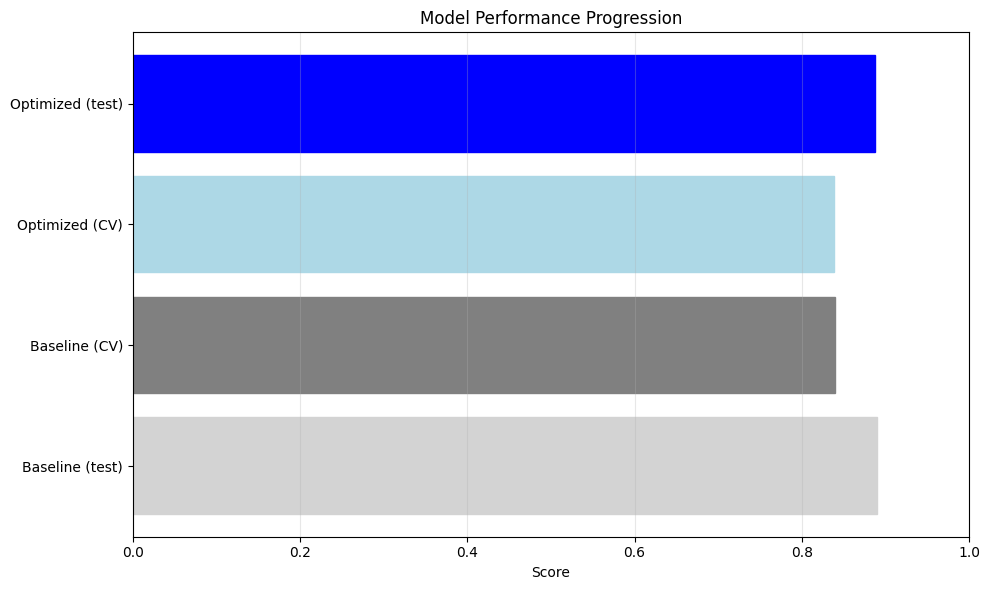


💡 Improvement from tuning: -0.26%


In [17]:
comparison_df = pd.DataFrame({
    'Model': ['Baseline (test)', 'Baseline (CV)', 'Optimized (CV)', 'Optimized (test)'],
    'Accuracy': [
        baseline_score,
        cv_baseline['mean'],
        grid_results['best_score'],
        final_score
    ],
    'Std': [None, cv_baseline['std'], None, None]
})

print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)
print(comparison_df)

# Visualize comparison
plt.figure(figsize=(10, 6))
bars = plt.barh(comparison_df['Model'], comparison_df['Accuracy'])
bars[0].set_color('lightgray')
bars[1].set_color('gray')
bars[2].set_color('lightblue')
bars[3].set_color('blue')
plt.xlabel('Score')
plt.title('Model Performance Progression')
plt.xlim(0, 1)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print(f"\n💡 Improvement from tuning: {(final_score - baseline_score)*100:.2f}%")

## Feature Analysis

In [18]:
if hasattr(best_model, 'feature_importances_'):
    print("\n" + "="*70)
    print("FEATURE IMPORTANCE")
    print("="*70)
    
    importances = best_model.feature_importances_
    feature_names = preprocessor.get_feature_names()
    
    # Sort and plot top 10
    indices = np.argsort(importances)[-10:]
    
    plt.figure(figsize=(10, 6))
    plt.barh(range(len(indices)), importances[indices], color='steelblue')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('Importance')
    plt.title('Top 10 Feature Importances')
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
    
    print("\n💡 Most important features:")
    for idx in indices[::-1][:5]:  # Top 5
        print(f"   • {feature_names[idx]}: {importances[idx]:.4f}")

## Key Insights & Summary

In [19]:
print("\n" + "="*70)
print("KEY INSIGHTS")
print("="*70)
print(f"\n✓ Baseline score: {baseline_score:.4f}")
print(f"✓ Optimized score: {final_score:.4f}")
print(f"✓ Improvement: {(final_score - baseline_score)*100:.2f}%")
print(f"\n✓ Best hyperparameters found:")
for param, value in grid_results['best_params'].items():
    print(f"   • {param}: {value}")


KEY INSIGHTS

✓ Baseline score: 0.8900
✓ Optimized score: 0.8873
✓ Improvement: -0.26%

✓ Best hyperparameters found:
   • n_estimators: 50
   • random_state: 42
